# Carga de datos.

In [146]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O
import matplotlib.pylab as plt
from scipy import stats
import os # accessing directory structure

import seaborn as sns
sns.set_theme(color_codes=True)

df1 = pd.read_csv('data/chickweight.csv', delimiter=',')

### Exploración de datos

In [147]:
df1.dataframeName = 'chickweight.csv'
nRow, nCol = df1.shape
print(f'Tenemos {nRow} filas y {nCol} columnas.')

print(f'Sabemos que los datos son obtenidos de un estudio con pollos.')
print(f'La columna Time, indica la edad en días del pollo.                      Entero entre {df1.Time.min()} y {df1.Time.max()}')
print(f'La columna Chick, indica el identificador único para cada pollo.        Entero entre {df1.Chick.min()} y {df1.Chick.max()}')
print(f'La columna Diet, indica el tipo de dieta que siguió ese pollo.          Entero entre {df1.Diet.min()} y {df1.Diet.max()}')
print(f'La columna Weight, indica el peso del pollo en el momento de medisión.  Entero entre {df1.weight.min()} y {df1.weight.max()}')

Tenemos 578 filas y 4 columnas.
Sabemos que los datos son obtenidos de un estudio con pollos.
La columna Time, indica la edad en días del pollo.                      Entero entre 0 y 21
La columna Chick, indica el identificador único para cada pollo.        Entero entre 1 y 50
La columna Diet, indica el tipo de dieta que siguió ese pollo.          Entero entre 1 y 4
La columna Weight, indica el peso del pollo en el momento de medisión.  Entero entre 35 y 373


In [148]:
df1.groupby('Time').agg(
    min_weight=('weight', 'min'),
    max_weight=('weight', 'max'),
    avg_weight=('weight', 'mean'),
    num_chicks=('Chick', 'count'),
    total_weight=('weight', 'sum'),
)

,min_weight,max_weight,avg_weight,num_chicks,total_weight
Time,,,,,
0,39,43,41.060000,50,2053
2,35,55,49.220000,50,2461
4,48,69,59.959184,49,2938
6,51,96,74.306122,49,3641
8,57,131,91.244898,49,4471
10,51,163,107.836735,49,5284
12,54,217,129.244898,49,6333
14,68,240,143.812500,48,6903
16,71,287,168.085106,47,7900


# Preprocesamiento

### Pivotamos los datos para identificar los pollos que no llegaron a final del experimento, y por tanto, sus datos faltan.

In [149]:
chicks_pivot = df1.pivot_table(values="weight", index=['Chick', 'Diet'], columns='Time')
chicks_pivot.head(10)

,Time,0,2,4,6,8,10,12,14,16,18,20,21
Chick,Diet,,,,,,,,,,,,
1,1,42.0,51.0,59.0,64.0,76.0,93.0,106.0,125.0,149.0,171.0,199.0,205.0
2,1,40.0,49.0,58.0,72.0,84.0,103.0,122.0,138.0,162.0,187.0,209.0,215.0
3,1,43.0,39.0,55.0,67.0,84.0,99.0,115.0,138.0,163.0,187.0,198.0,202.0
4,1,42.0,49.0,56.0,67.0,74.0,87.0,102.0,108.0,136.0,154.0,160.0,157.0
5,1,41.0,42.0,48.0,60.0,79.0,106.0,141.0,164.0,197.0,199.0,220.0,223.0
6,1,41.0,49.0,59.0,74.0,97.0,124.0,141.0,148.0,155.0,160.0,160.0,157.0
7,1,41.0,49.0,57.0,71.0,89.0,112.0,146.0,174.0,218.0,250.0,288.0,305.0
8,1,42.0,50.0,61.0,71.0,84.0,93.0,110.0,116.0,126.0,134.0,125.0,NaN
9,1,42.0,51.0,59.0,68.0,85.0,96.0,90.0,92.0,93.0,100.0,100.0,98.0


### Eliminamos los datos faltantes y volvemos al formato inicial de los datos.

In [150]:
chicks_pivot = chicks_pivot.dropna();
chicks = chicks_pivot.stack().reset_index(name='weight')

In [151]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
	chicks,
	title="Pollos Hermanos - EDA inicial",
	explorative=True,
)
profile.to_file("reportes/eda_pollos.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:00<00:00, 4162.05it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

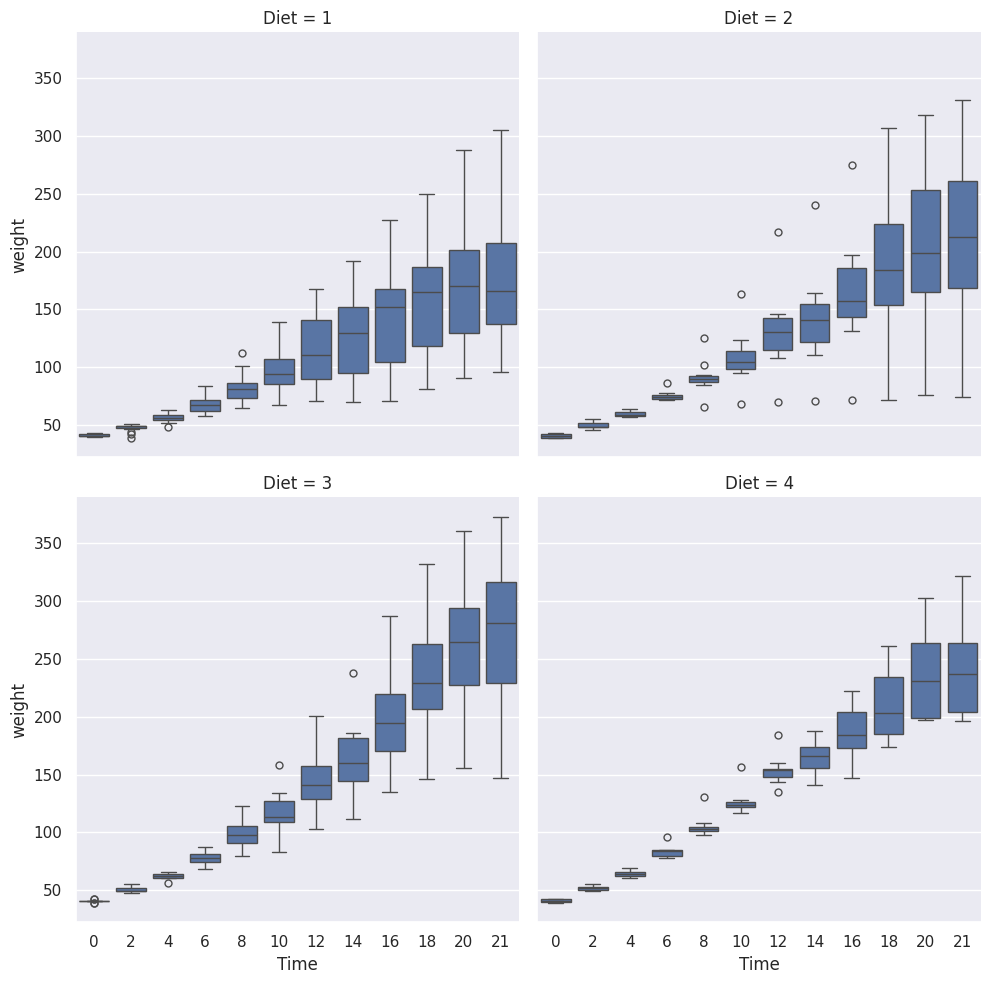

In [152]:
sns.catplot(x="Time", y="weight", col="Diet", data=chicks, kind="box", col_wrap=2)

In [153]:
# y = WEIGHT -> target
y = chicks.weight
# X = ["Diet", "Time"] -> features
features = ["Diet", "Time"]
X = chicks[features]

In [154]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error


### Primera corrida

In [155]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

def pipe(modelo):
    """Imputa -> escala -> ajusta el modelo, todo dentro de un mismo Pipeline."""
    return Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
        ("modelo", modelo),
    ])

# Modelo entrenado

In [156]:
ols = pipe(LinearRegression()).fit(X_train, y_train)
pred = ols.predict(X_test)

print(f"OLS -> R² test = {r2_score(y_test, pred):.3f} | MAE = {mean_absolute_error(y_test, pred):.2f} gramos")


OLS -> R² test = 0.727 | MAE = 26.67 gramos


Text(0.5, 1.0, 'QQ-plot de residuos')

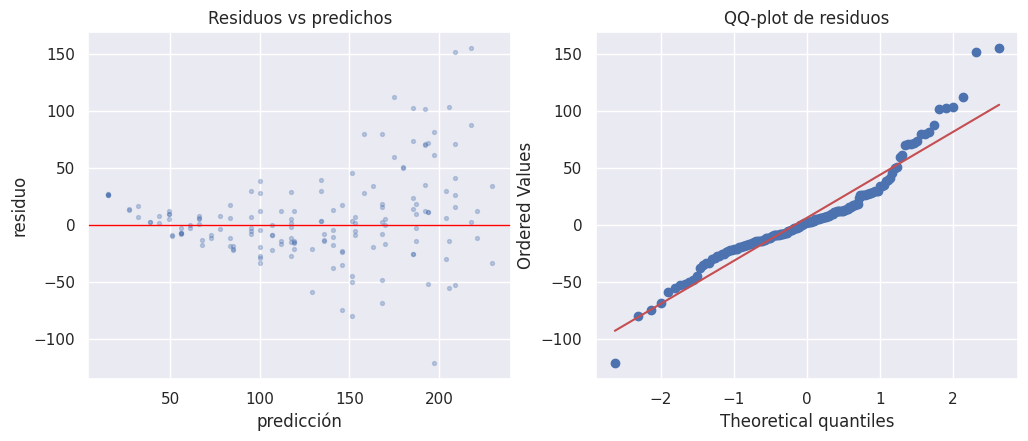

In [157]:
residuos = y_test - pred

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].scatter(pred, residuos, s=8, alpha=0.3)
ax[0].axhline(0, color="red", lw=1)
ax[0].set_xlabel("predicción"); ax[0].set_ylabel("residuo")
ax[0].set_title("Residuos vs predichos")

stats.probplot(residuos, dist="norm", plot=ax[1])
ax[1].set_title("QQ-plot de residuos")

### El modelo probado presenta heterocedasticidad y no linealidad. Se recomienda probar un modelo más complejo.

In [158]:
grid_ridge = GridSearchCV(
    pipe(Ridge()), {"modelo__alpha": np.logspace(-2, 4, 20)}, scoring="r2", cv=5
).fit(X_train, y_train)

grid_lasso = GridSearchCV(
    pipe(Lasso(max_iter=10000)), {"modelo__alpha": np.logspace(-3, 1, 20)}, scoring="r2", cv=5
).fit(X_train, y_train)

In [159]:
modelos = {
    "RegLin": LinearRegression(),
    "Ridge (CV)": grid_ridge.best_estimator_,
    "Lasso (CV)": grid_lasso.best_estimator_,
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000),
}

In [160]:
filas = []
for nombre, m in modelos.items():
    score_r2 = cross_val_score(m, X, y, cv=5, scoring="r2")
    score_mae = cross_val_score(m, X, y, cv=5, scoring="neg_mean_absolute_error")

    #n_feat = int(np.sum(np.abs(m.named_steps["modelo"].coef_) > 1e-6))
    filas.append({
        "modelo": nombre,
        "R2_best": round(max(score_r2), 3),
        "R2_media": round(score_r2.mean(), 3),
        "MAE_test": round(score_mae.mean(), 3),
        #"features_usadas": n_feat,
    })


pd.DataFrame(filas).set_index("modelo")

,R2_best,R2_media,MAE_test
modelo,,,
RegLin,0.810,0.691,-27.837
Ridge (CV),0.810,0.691,-27.797
Lasso (CV),0.814,0.691,-27.729
ElasticNet,0.812,0.691,-27.789


## Evaluación sobre test

Media de los residuos: -2.267 (esperado ≈ 0)
Media de los residuos: -2.259 (esperado ≈ 0)
Media de los residuos: -2.244 (esperado ≈ 0)
Media de los residuos: -2.235 (esperado ≈ 0)


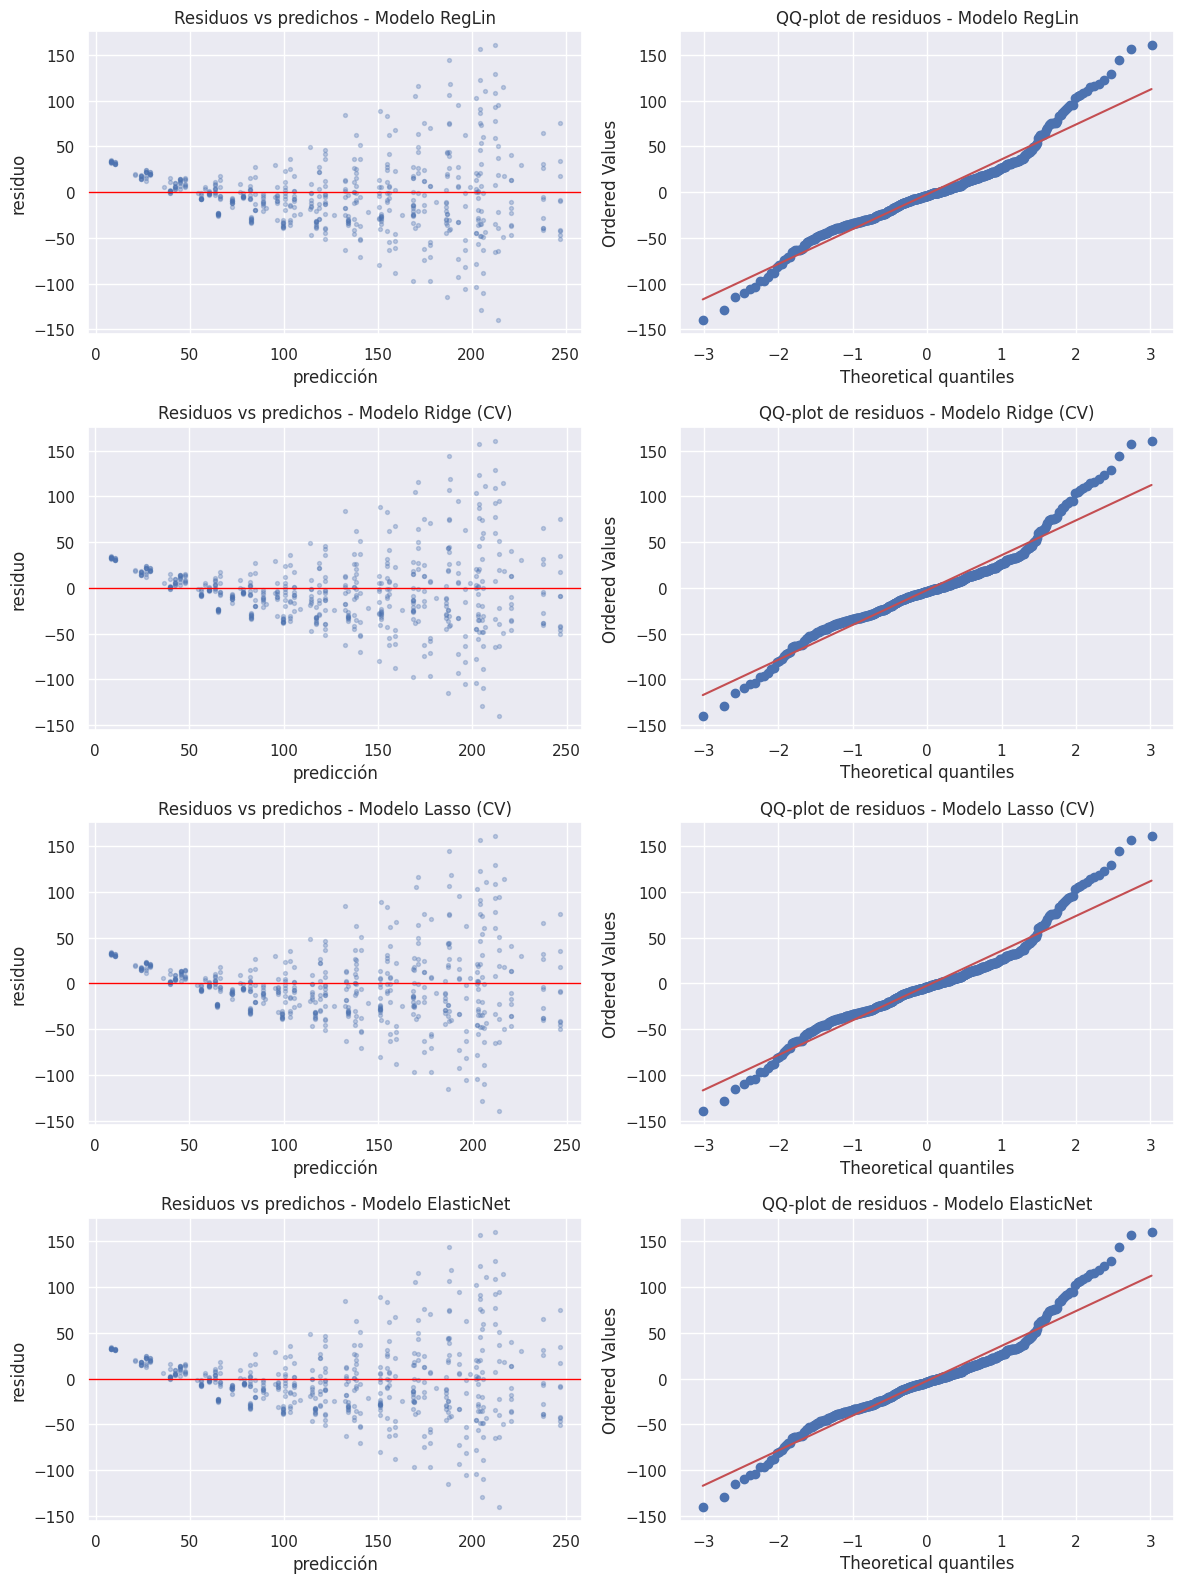

In [161]:
fig, ax = plt.subplots(4, 2, figsize=(12, 16))
i=0
j=0

for nombre, m in modelos.items():
    pred = cross_val_predict(m,X, y, cv=5)
    residuos = y - pred

    ax[i, 0].scatter(pred, residuos, s=8, alpha=0.3)
    ax[i, 0].axhline(0, color="red", lw=1)
    ax[i, 0].set_xlabel("predicción"); ax[i, 0].set_ylabel("residuo")
    ax[i, 0].set_title(f"Residuos vs predichos - Modelo {nombre}")

    stats.probplot(residuos, dist="norm", plot=ax[i, 1])
    ax[i, 1].set_title(f"QQ-plot de residuos - Modelo {nombre}")
    
    i=i+1

    print(f"Media de los residuos: {residuos.mean():.3f} (esperado ≈ 0)")
fig.tight_layout(); plt.show()